# Test farfield calculations

We carry out a simple test to check the farfield calculations.

In [1]:
%matplotlib widget

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from PyPO.System import System
from PyPO.Enums import FieldComponents, CurrentComponents, Units, Scales


In [5]:
# Sanity check installation of PyPO
import PyPO
import os, datetime

pypo_file = PyPO.__file__
pypo_dir = os.path.dirname(pypo_file)
print(pypo_dir)
fp_time = datetime.datetime.fromtimestamp(os.path.getmtime(pypo_file))
print(f"Installed {fp_time}")


print("Shared library installed times")
pypo_files = os.listdir(pypo_dir)
compiled_files = []
for f in pypo_files:
    if f.endswith('.so'):
        compiled_files.append(f)
        fp = os.path.join(pypo_dir, f)
        fp_time = datetime.datetime.fromtimestamp(os.path.getmtime(fp))
        print(f"{f:18s} : {fp_time}")
        
print()
print("Build times in active branch")
for f in compiled_files:
    path = os.path.join('../build/lib.linux-x86_64-cpython-314/PyPO/', f)
    fp_time = datetime.datetime.fromtimestamp(os.path.getmtime(path))
    print(f"{f:18s} : {fp_time}")
        

/home/pgrimes/miniforge3/envs/pypo_gfc/lib/python3.14/site-packages/PyPO
Installed 2026-03-04 14:01:01.481424
Shared library installed times
libpyporefl.so     : 2026-03-04 14:01:01.489424
libpypogpu.so      : 2026-03-04 14:01:01.489424
libpypocpu.so      : 2026-03-04 14:01:01.485424
libpypobeam.so     : 2026-03-04 14:01:01.481424
libpypotransf.so   : 2026-03-04 14:01:01.489424

Build times in active branch
libpyporefl.so     : 2026-03-05 09:21:32.011816
libpypogpu.so      : 2026-03-05 10:23:57.847079
libpypocpu.so      : 2026-03-05 09:21:34.319815
libpypobeam.so     : 2026-03-05 09:21:32.559816
libpypotransf.so   : 2026-03-05 09:21:32.979816


In [6]:
%pwd

'/home/pgrimes/github/PyPO/tests'

In [7]:
s = System()

2026-03-05 10:24:31 - WARNING - System override set to True. 


We set up a simple uniform source on a disk, and propagate that to the farfield.

In [8]:
# Setting up parameters for defining simulation.
# Source parameters and distances
lam = 1*Units.MM                # Wavelength of light in mm

w0 = 5*Units.MM  # Gaussian beamwaist

E0 = np.sqrt(8/(w0**2)) # Normalise to 4pi Watts
print(f"Field normalization       : {E0:.3g} √Watt")

theta_0 = np.rad2deg(np.atan(lam/(np.pi*w0))) # Calculate far-field divergence angle
print(f"Farfield divergence angle : {theta_0:.3f}°")

fwhm = 1.18*theta_0
print(f"Farfield FWHM angle       : {fwhm:.3f}°")


r_disk = 5*w0               # Radius of disk in mm
print(f"Radius of source grid     : {r_disk:.3f} mm")

Field normalization       : 0.566 √Watt
Farfield divergence angle : 3.643°
Farfield FWHM angle       : 4.298°
Radius of source grid     : 25.000 mm


In [9]:
# Setting up surface dictionaries and source current distributions.
disk = {
        "name"      : "disk",
        "gmode"     : "uv",
        "lims_u"    : np.array([0, r_disk]),
        "lims_v"    : np.array([0, 360])*Units.DEG,
        "gridsize"  : np.array([201, 180])
        }

s.addPlane(disk)

udict = {                         
            "name"      : "source",                                                                                                                                  
            "lam"       : 1*Units.MM,                                                                                                                                                                                                                                                                                                                            
            "E0"        : 1,                                                                                                                                  
            "dxyz"      : 0,                                                                                                 
            "pol"       : np.array([1, 0, 0])
}                                                                                                          

GPODict = {
        "name"  : "source",
        "lam"   : lam,
        "w0x"   : w0,
        "w0y"   : w0,
        "n"     : 1.0,
        "dxyx"  : 0.0,
        "E0"    : E0,
        "pol"   : np.array([1, 0, 0])
}

#s.createUniformSource(udict, "disk")
s.createGaussian(GPODict, "disk")

2026-03-05 10:24:34 - INFO - Added plane disk to system. 


In [10]:
#s.plotBeam2D("source", FieldComponents.Ex, norm=False)
#s.plotBeam2D("source", CurrentComponents.My, norm=False)


# Calculate farfield

In [11]:
# Set up the farfield grid

size = fwhm*5

farfield = {
            "name"      : "farfield",
            "gmode"     : "AoE",
            "lims_Az"    : np.array([-size, size])*Units.DEG,
            "lims_El"    : np.array([-size, size])*Units.DEG,
            "gridsize"  : np.array([101, 101])
            }

s.addPlane(farfield)

2026-03-05 10:24:37 - INFO - Added plane farfield to system. 


In [12]:
pri_to_ff = {
        "t_name"    : "farfield",
        "s_current" : "source",
        "mode"      : "FF",
        "name_EH"   : "EH_ff",
        "device"    : "GPU"
        }

s.runPO(pri_to_ff)

2026-03-05 10:24:38 - WORK - *** Starting PO propagation *** 
2026-03-05 10:24:38 - WORK - Propagating source on disk to farfield, propagation mode: FF. 
2026-03-05 10:24:38 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-05 10:24:38 - WORK - ... Calculating ... 
2026-03-05 10:24:38 - WORK - *** Finished: 0.454 seconds *** 


Units.MM
mm


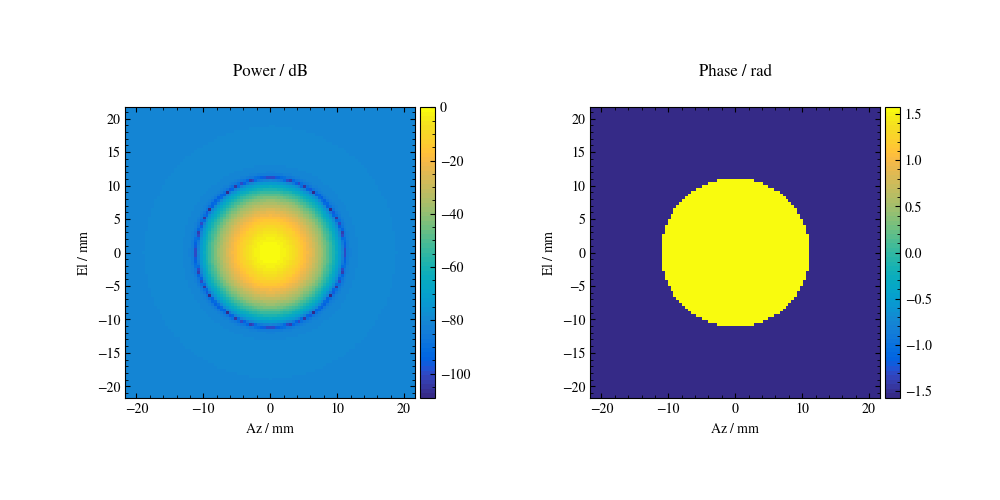

Units.MM
mm


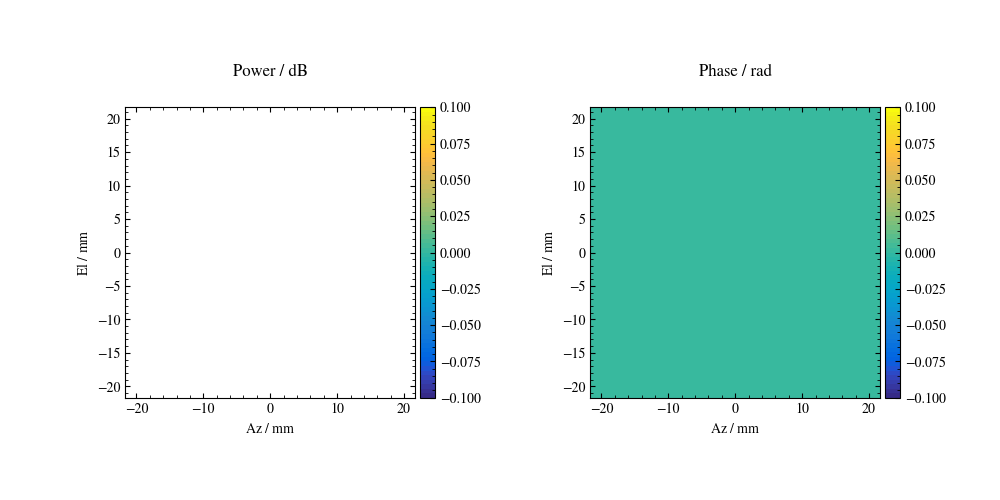

Units.MM
mm


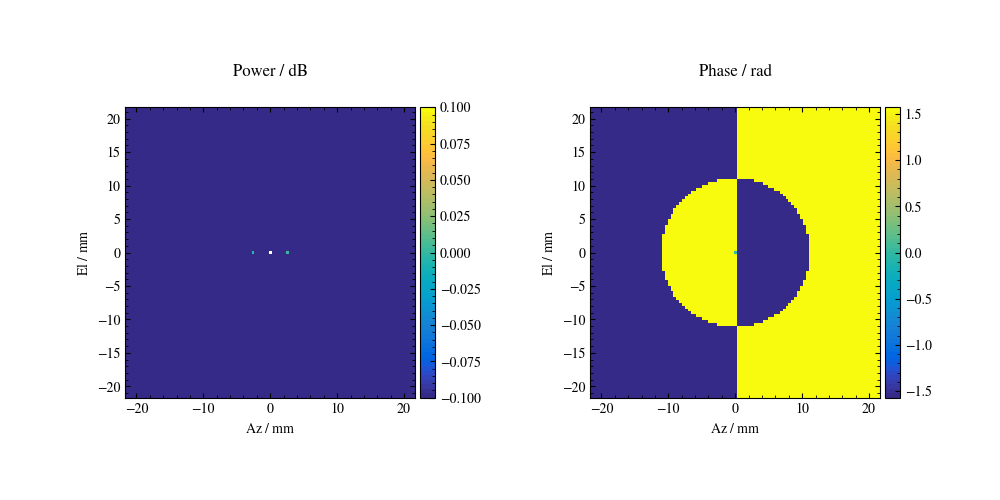

In [13]:
s.plotBeam2D("EH_ff", FieldComponents.Ex, norm=False)
s.plotBeam2D("EH_ff", FieldComponents.Ey, norm=False)
s.plotBeam2D("EH_ff", FieldComponents.Ez, norm=False)

Units.MM
mm


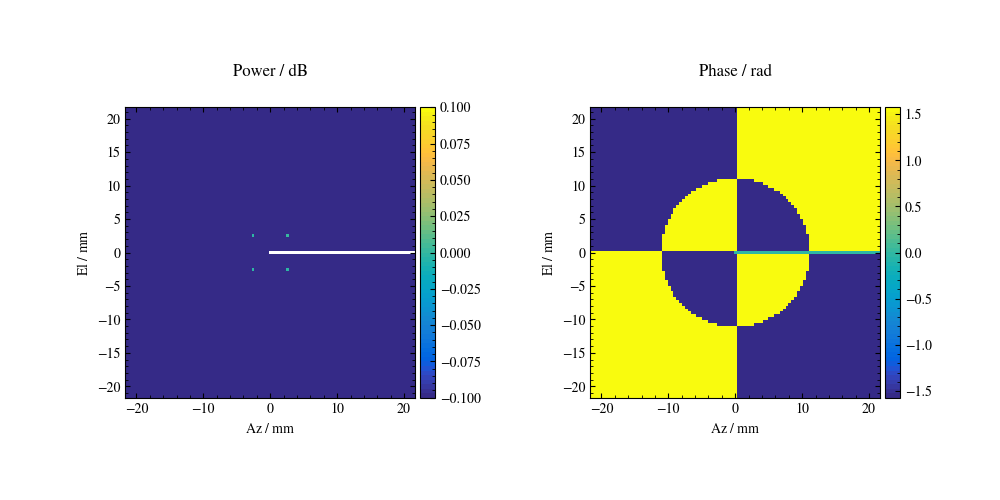

Units.MM
mm


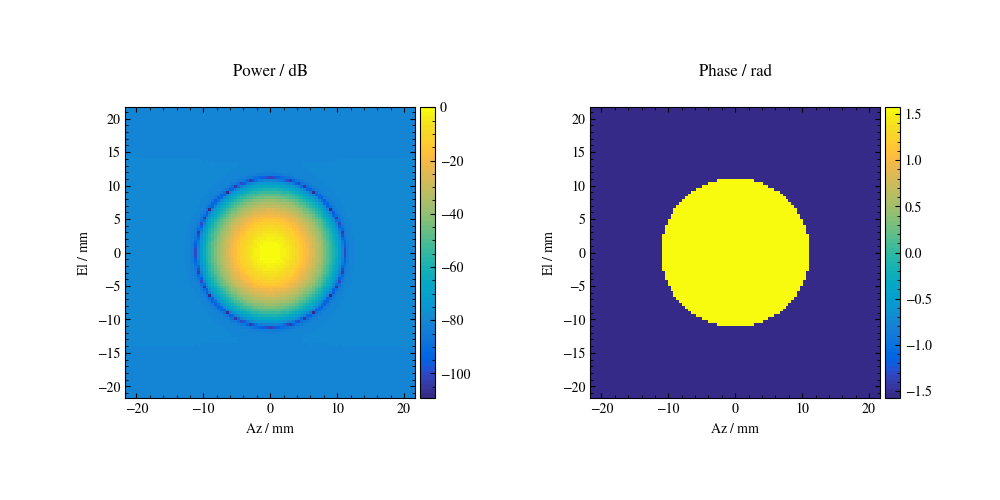

Units.MM
mm


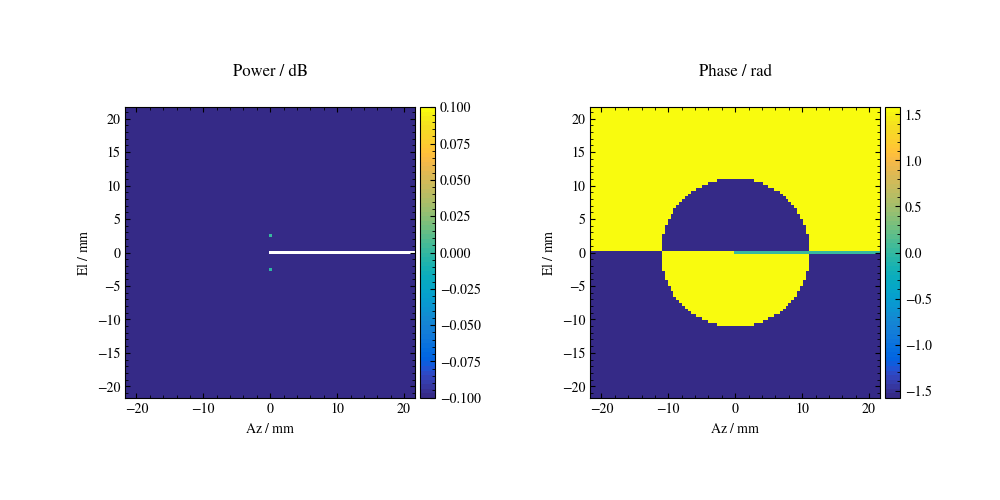

In [14]:
s.plotBeam2D("EH_ff", FieldComponents.Hx, norm=False)
s.plotBeam2D("EH_ff", FieldComponents.Hy, norm=False)
s.plotBeam2D("EH_ff", FieldComponents.Hz, norm=False)

In [19]:
grid = s.generateGrids("farfield")

Text(0, 0.5, 'Phase (rad)')

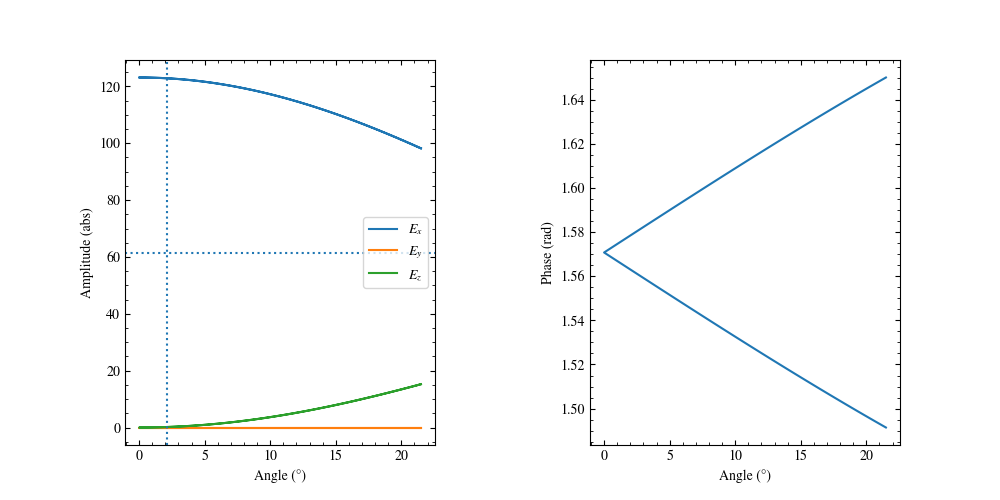

In [20]:
field = 'EH_ff'

row = 50

fig, ax = plt.subplots(1,2, figsize=(10,5), gridspec_kw={'wspace':0.5})
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Ex[:,row])**2, label='$E_x$')
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Ey[:,row])**2, label='$E_y$')
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Ez[:,row])**2, label='$E_z$')
ax[0].axvline(fwhm/2, ls=":")
ax[0].axhline(np.max(np.abs(s.fields[field].Ex[:,row])**2)/2, ls=":")
ax[0].legend()
ax[0].set_xlabel('Angle (°)')
ax[0].set_ylabel('Amplitude (abs)')

ax[1].plot(np.rad2deg(grid.x[:,row]), np.unwrap(np.angle(s.fields[field].Ex[:,row])))
ax[1].set_xlabel('Angle (°)')
ax[1].set_ylabel('Phase (rad)')

Text(0, 0.5, 'Phase (rad)')

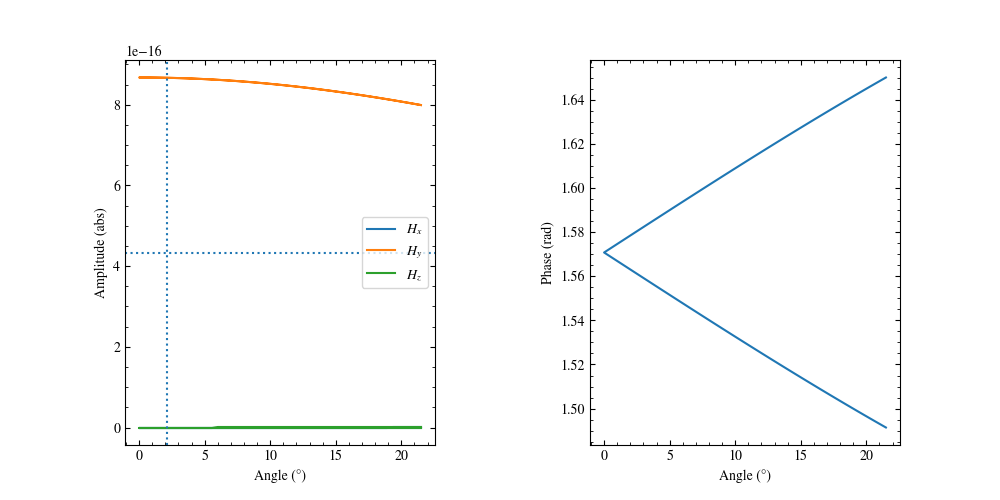

In [21]:
fig, ax = plt.subplots(1,2, figsize=(10,5), gridspec_kw={'wspace':0.5})
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Hx[:,row])**2, label='$H_x$')
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Hy[:,row])**2, label='$H_y$')
ax[0].plot(np.rad2deg(grid.x[:,row]), np.abs(s.fields[field].Hz[:,row])**2, label='$H_z$')
ax[0].axvline(fwhm/2, ls=":")
ax[0].axhline(np.max(np.abs(s.fields[field].Hy[:,row])**2)/2, ls=":")
ax[0].legend()
ax[0].set_xlabel('Angle (°)')
ax[0].set_ylabel('Amplitude (abs)')

ax[1].plot(np.rad2deg(grid.x[:,row]), np.unwrap(np.angle(s.fields[field].Hy[:,row])))
ax[1].set_xlabel('Angle (°)')
ax[1].set_ylabel('Phase (rad)')

# Calculate nearfield

In [22]:
# Set up the farfield grid
z = r_disk*5

wz = w0*np.sqrt(1+ (lam*z)/(np.pi*w0**2))

size = wz*2.5

nearfield = {
            "name"      : "nearfield",
            "gmode"     : "uv",
            "lims_u"    : np.array([0, size]),
            "lims_v"    : np.array([0, 360])*Units.DEG,
            "gridsize"  : np.array([101, 180])
            }

s.addPlane(nearfield)
s.translateGrids('nearfield', np.array([0, 0, z]))


print(f"Expected beam size $w_z$ : {wz:.3f} mm")

2026-03-05 09:54:49 - INFO - Added plane nearfield to system. 
2026-03-05 09:54:49 - INFO - Translated element nearfield by ('0.000e+00', '0.000e+00', '1.250e+02') millimeters. 
Expected beam size $w_z$ : 8.049 mm


In [23]:
pri_to_nf = {
        "t_name"    : "nearfield",
        "s_current" : "source",
        "mode"      : "EH",
        "name_EH"   : "EH_nf",
        "device"    : "GPU"
        }

s.runPO(pri_to_nf)

2026-03-05 09:54:51 - WORK - *** Starting PO propagation *** 
2026-03-05 09:54:51 - WORK - Propagating source on disk to nearfield, propagation mode: EH. 
2026-03-05 09:54:51 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-05 09:54:51 - WORK - ... Calculating ... 
2026-03-05 09:54:51 - WORK - *** Finished: 0.278 seconds *** 


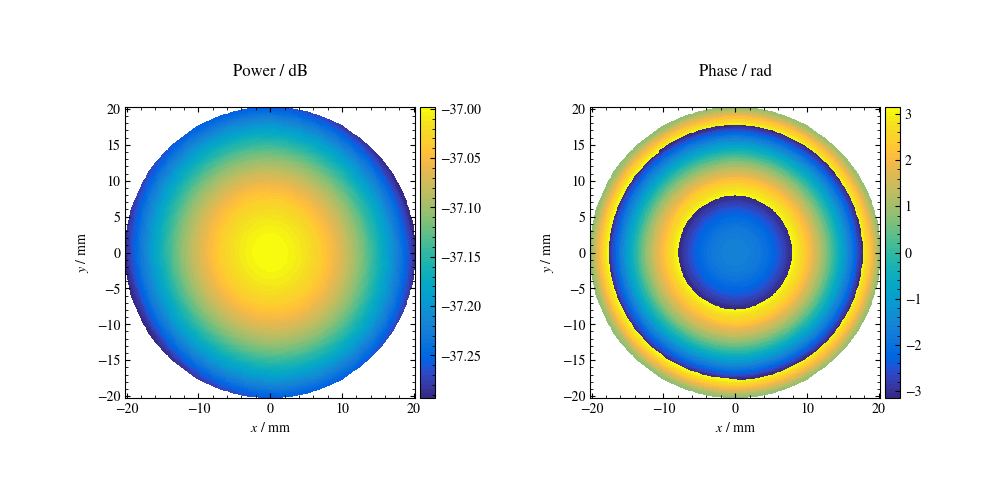

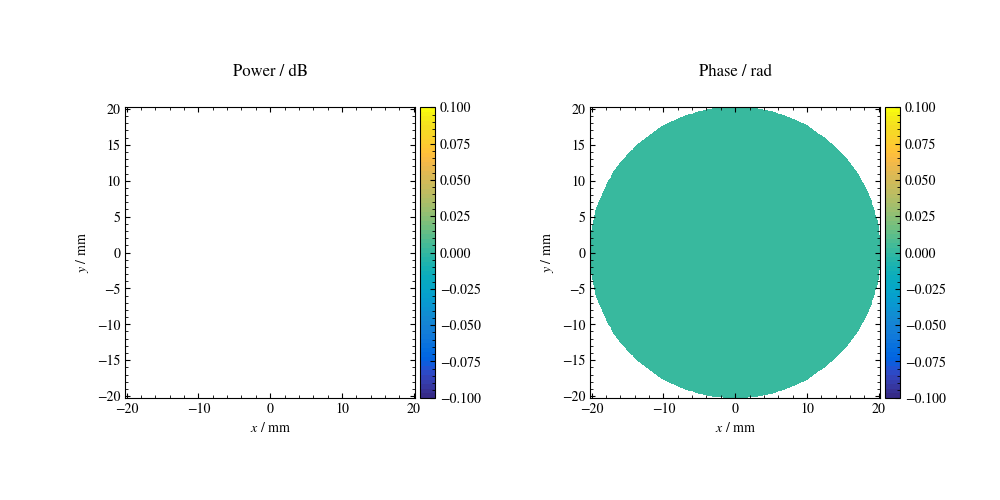

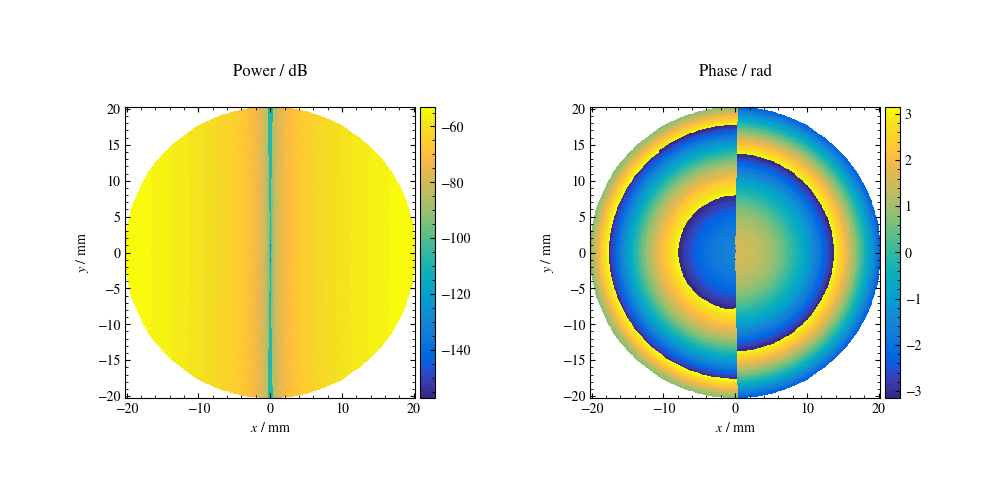

In [24]:
s.plotBeam2D("EH_nf", FieldComponents.Ex, norm=False)
s.plotBeam2D("EH_nf", FieldComponents.Ey, norm=False)
s.plotBeam2D("EH_nf", FieldComponents.Ez, norm=False)

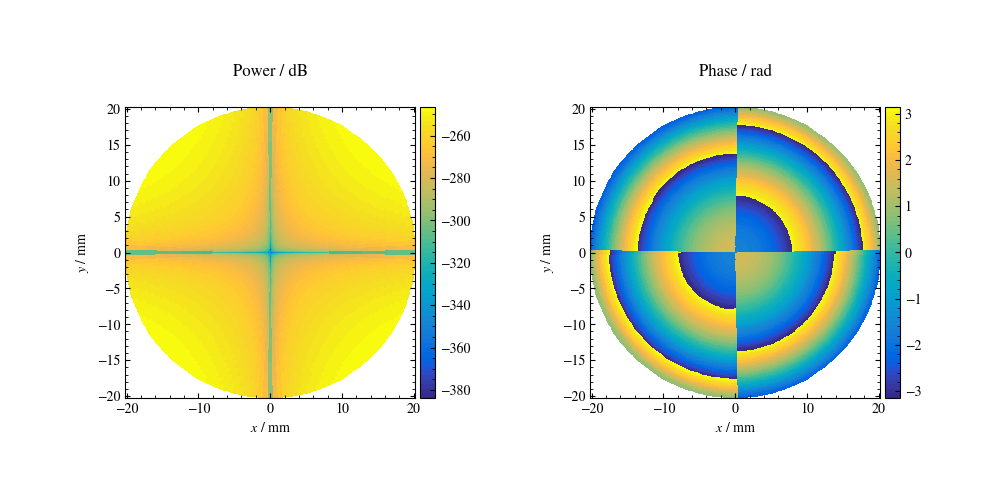

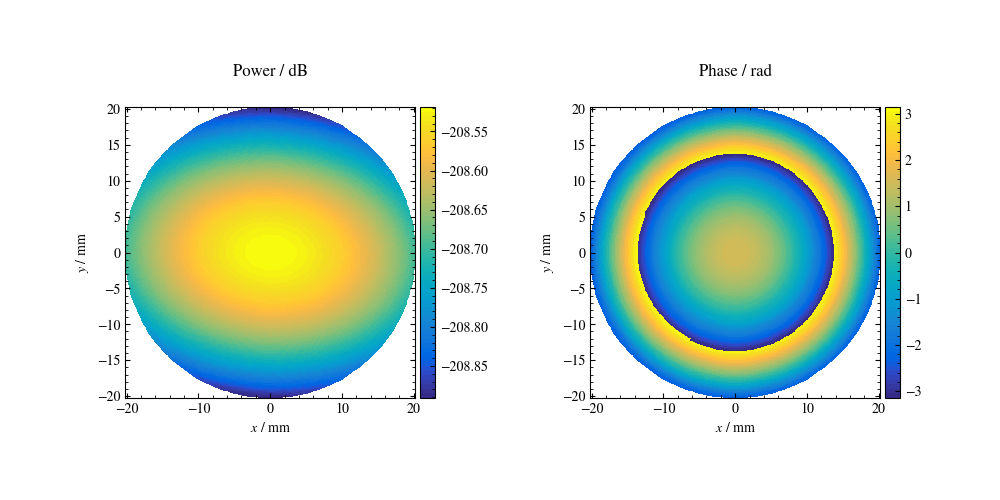

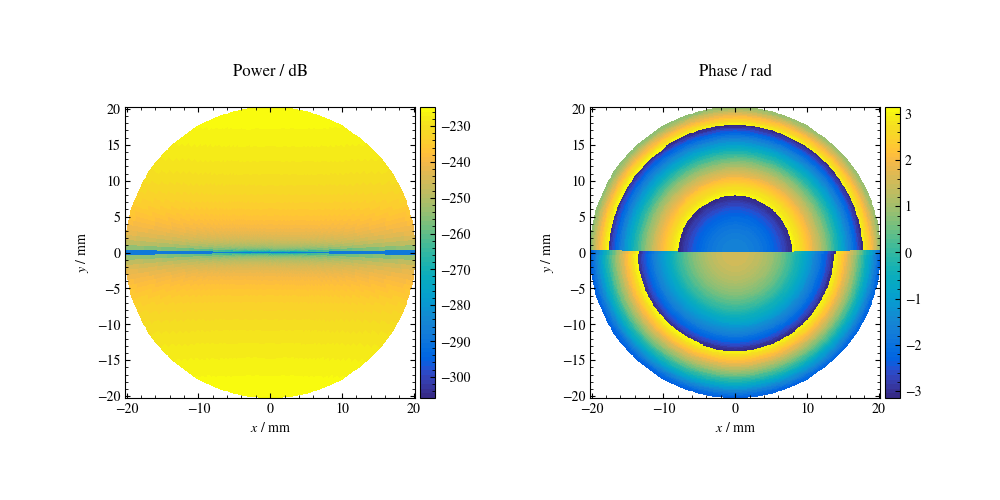

In [25]:
s.plotBeam2D("EH_nf", FieldComponents.Hx, norm=False)
s.plotBeam2D("EH_nf", FieldComponents.Hy, norm=False)
s.plotBeam2D("EH_nf", FieldComponents.Hz, norm=False)

In [26]:
grid = s.generateGrids("nearfield")

Text(0, 0.5, 'Phase (rad)')

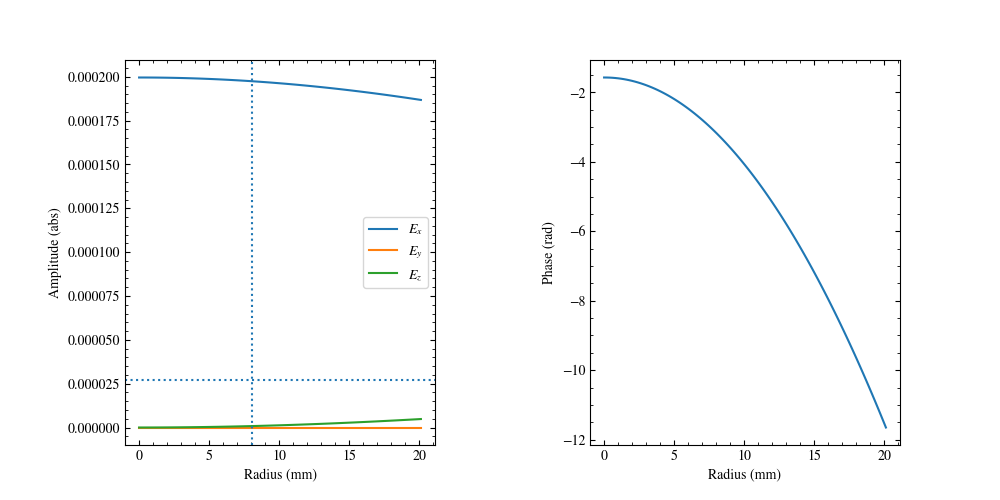

In [27]:
field = 'EH_nf'

row = 0

fig, ax = plt.subplots(1,2, figsize=(10,5), gridspec_kw={'wspace':0.5})
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Ex[:,row])**2, label='$E_x$')
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Ey[:,row])**2, label='$E_y$')
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Ez[:,row])**2, label='$E_z$')
ax[0].axvline(wz, ls=":")
ax[0].axhline(np.max(np.abs(s.fields[field].Ex[:,row])**2)/np.exp(1)**2, ls=":")
ax[0].legend()
ax[0].set_xlabel('Radius (mm)')
ax[0].set_ylabel('Amplitude (abs)')

ax[1].plot(grid.x[:,row], np.unwrap(np.angle(s.fields[field].Ex[:,row])))
ax[1].set_xlabel('Radius (mm)')
ax[1].set_ylabel('Phase (rad)')

Text(0, 0.5, 'Phase (rad)')

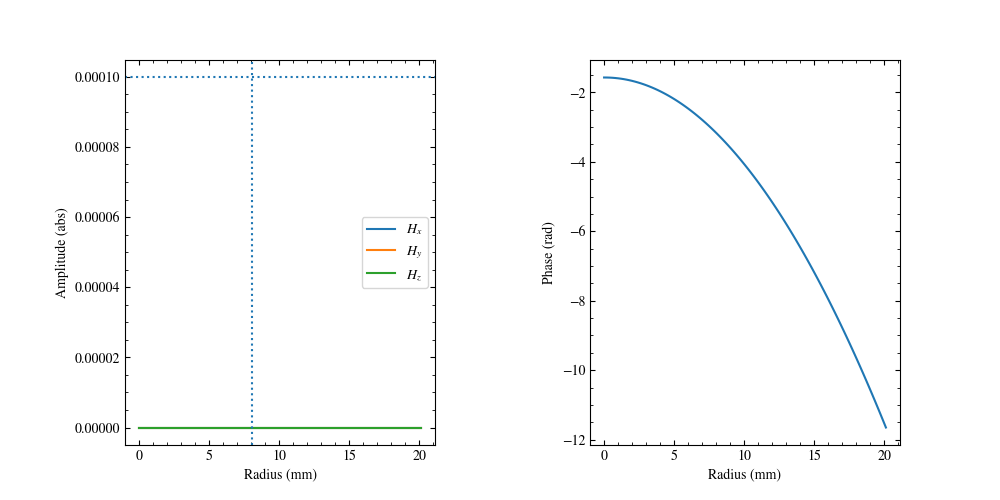

In [28]:
fig, ax = plt.subplots(1,2, figsize=(10,5), gridspec_kw={'wspace':0.5})
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Hx[:,row])**2, label='$H_x$')
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Hy[:,row])**2, label='$H_y$')
ax[0].plot(grid.x[:,row], np.abs(s.fields[field].Hz[:,row])**2, label='$H_z$')
ax[0].axvline(wz, ls=":")
ax[0].axhline(np.max(np.abs(s.fields[field].Ex[:,row])**2)/2, ls=":")
ax[0].legend()
ax[0].set_xlabel('Radius (mm)')
ax[0].set_ylabel('Amplitude (abs)')

ax[1].plot(grid.x[:,row], np.unwrap(np.angle(s.fields[field].Ex[:,row])))
ax[1].set_xlabel('Radius (mm)')
ax[1].set_ylabel('Phase (rad)')

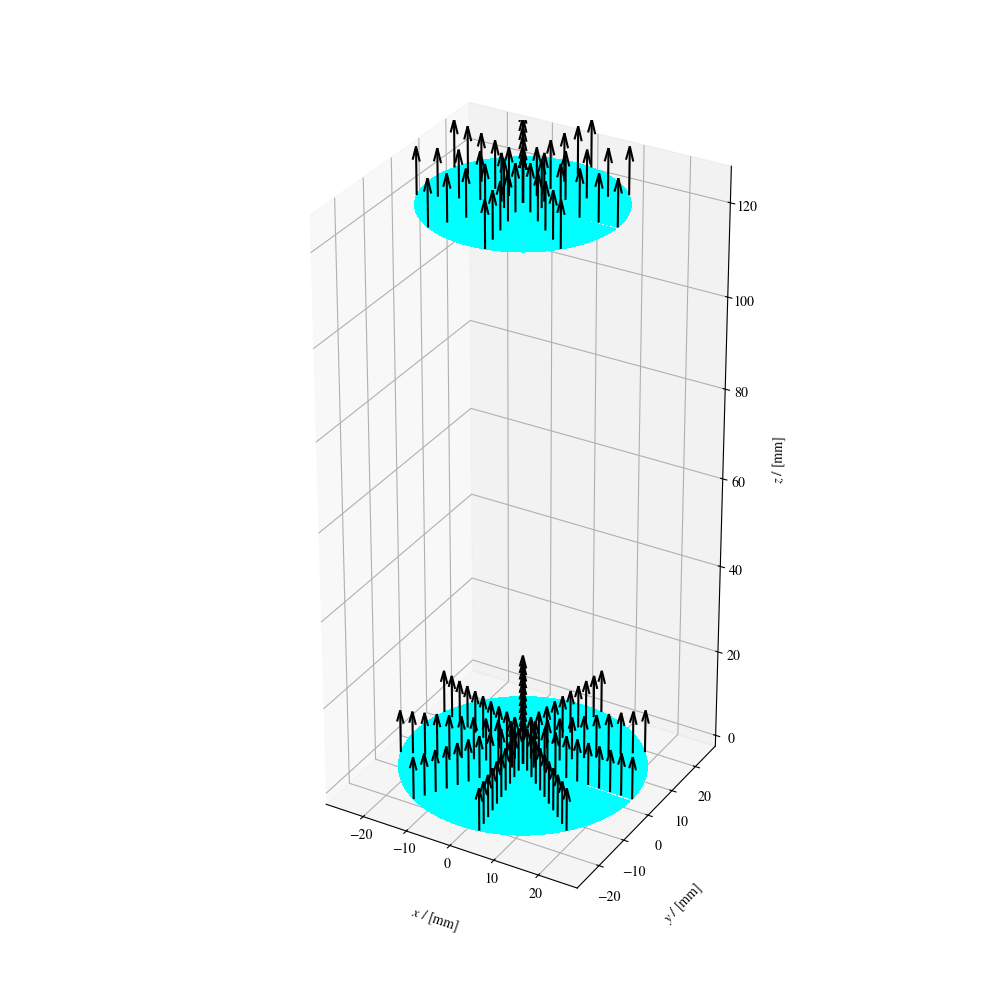

In [29]:
s.plotSystem(norm=True)